## 1. Environment Setup & Library Imports

In [9]:
# --- SETUP & IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, LabelEncoder
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
print("Libraries successfully loaded.")

Libraries successfully loaded.


## 2. Data Ingestion & Initial Cleaning

In [10]:
# --- INGESTION & FORMATTING ---
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Drop the customerID column (holds no predictive value)
df.drop('customerID', axis=1, inplace=True)

# Coerce hidden blank spaces in TotalCharges to NaN, then force the column to numeric
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

print(f"Raw data loaded. Shape: {df.shape}")

Raw data loaded. Shape: (7043, 20)


## 3. Strict 70/30 Train-Test Split

In [11]:
# --- DATA ISOLATION (70/30 SPLIT) ---
X = df.drop('Churn', axis=1)
y = df['Churn']

# Stratify ensures the 70/30 split maintains the original ratio of churned vs. retained customers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training Features Matrix: {X_train.shape}")
print(f"Testing Features Vault: {X_test.shape}")

Training Features Matrix: (4930, 19)
Testing Features Vault: (2113, 19)


## 4. Handling Nulls & Feature Engineering

In [12]:
# --- IMPUTATION & FEATURE ENGINEERING ---
# 1. Fill NaNs with the Training Median
median_total = X_train['TotalCharges'].median()
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(median_total)
X_test['TotalCharges'] = X_test['TotalCharges'].fillna(median_total)

# 2. Feature Engineering: Convert raw monthly tenure into a 'Tenure_Years' metric for macro-analysis
X_train['Tenure_Years'] = X_train['tenure'] / 12.0
X_test['Tenure_Years'] = X_test['tenure'] / 12.0

print(f"Missing values handled. New feature 'Tenure_Years' successfully engineered.")

Missing values handled. New feature 'Tenure_Years' successfully engineered.


## 5. Categorical Encoding (Label & One-Hot)

In [13]:
# --- CATEGORICAL TRANSFORMATION ---
# Label Encoding for simple binary features
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
le = LabelEncoder()
for col in binary_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# Map Target Variable manually
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

# One-Hot Encoding for multi-class categorical features
nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)

# Align columns to ensure the test set matches the training set's exact structure
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Categorical encoding complete. Matrices aligned.")

Categorical encoding complete. Matrices aligned.


## 6. Normalization & Scaling

In [14]:
# --- NORMALIZATION & SCALING ---
# Normalization: Use Yeo-Johnson to fix the heavily skewed shape of TotalCharges
pt = PowerTransformer(method='yeo-johnson')
X_train[['TotalCharges']] = pt.fit_transform(X_train[['TotalCharges']])
X_test[['TotalCharges']] = pt.transform(X_test[['TotalCharges']])

# Scaling: MinMax scale all continuous variables to restrict them between 0 and 1
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Tenure_Years']
scaler = MinMaxScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Data distribution normalized. Continuous variables scaled.")

Data distribution normalized. Continuous variables scaled.


## 7. Class Balancing (SMOTE) & Visualizations

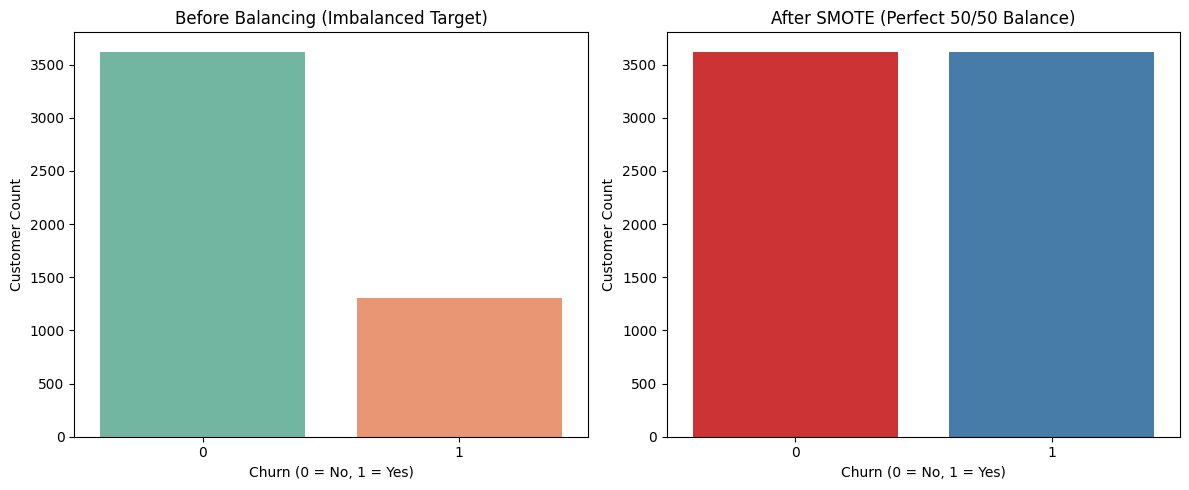


--- PROCESSED SAMPLE VERIFICATION ---
   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0       0              0        0           0  0.069444             1   
1       0              1        0           0  0.041667             1   
2       0              0        1           0  0.041667             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Tenure_Years  ...  \
0                 0        0.615845      0.307904      0.069444  ...   
1                 1        0.682113      0.232218      0.041667  ...   
2                 1        0.565521      0.229778      0.041667  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                            False             True   
1            False                            False             True   
2            False                            False            False   

   StreamingMovies_No internet service  StreamingMovies_Yes  \
0                          

In [15]:
# --- CLASS BALANCING & VISUAL MATRICES ---
plt.figure(figsize=(12, 5))

# Plot 1: Before Balancing
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='Set2')
plt.title('Before Balancing (Imbalanced Target)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Customer Count')

# Execute SMOTE (Synthetic Minority Over-sampling Technique)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Plot 2: After Balancing
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_balanced, palette='Set1')
plt.title('After SMOTE (Perfect 50/50 Balance)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Customer Count')

plt.tight_layout()
plt.show()

print("\n--- PROCESSED SAMPLE VERIFICATION ---")
print(X_train_balanced.head(3))

## 8. Final Dataset Export

In [16]:
# --- CELL 8: FILE EXPORT ---
# Recombine features and targets for the training set
train_processed = pd.concat([pd.DataFrame(X_train_balanced, columns=X_train.columns), pd.Series(y_train_balanced, name='Churn')], axis=1)

# Recombine features and targets for the untouched test set
test_processed = pd.concat([pd.DataFrame(X_test, columns=X_test.columns), pd.Series(y_test.reset_index(drop=True), name='Churn')], axis=1)

# Export to CSV without the pandas index column
train_processed.to_csv('final_clean_train_data.csv', index=False)
test_processed.to_csv('final_clean_test_data.csv', index=False)

print(f"Pipeline Complete. Exported Training Rows: {train_processed.shape[0]}")
print(f"Pipeline Complete. Exported Testing Rows: {test_processed.shape[0]}")

Pipeline Complete. Exported Training Rows: 7244
Pipeline Complete. Exported Testing Rows: 3609
